In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

-----------
# Ознайомлення з дата-сетом


In [186]:
df = pd.read_csv("../data/test_1_payment_data/test_1_payment_data.csv")
df.head(3)

,#,order_id,event_time,user_id,price,payment_number,transaction_status,card_brand,card_type,bank_name,error_type,currency,card_country
0,1,c500aa10-30f8-4927-96c5-4e97b6afac83,2022-07-08 18:32:39.000000,c1ed5188-caac-4d56-bad8-bc8ee0b09960,21.0,reccurent,fail,VISA,PREPAID,ADVANCED BANK OF ASIA LIMITED,3.08,USD,KHM
1,2,624d6f30-c1bc-4778-a23e-6a227bac73ac,2022-06-09 22:18:36.000000,c9ff65b8-75e6-467f-8715-21edb5fd06af,36.0,reccurent,fail,VISA,PREPAID,UNITED BANK FOR AFRICA GHANA LIMITED,3.02,USD,GHA
2,3,4d75ca57-8883-49a9-b150-1ab7a47d12f8,2022-06-09 11:18:32.000000,1005d4fb-1b7d-4715-835f-4d2a9bfe7cbb,36.0,initial,success,VISA,CREDIT,ICICI BANK LTD,NaN,USD,IND


In [187]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 566413 entries, 0 to 566412
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   #                   566413 non-null  int64  
 1   order_id            566413 non-null  str    
 2   event_time          566413 non-null  str    
 3   user_id             566413 non-null  str    
 4   price               566413 non-null  float64
 5   payment_number      566413 non-null  str    
 6   transaction_status  566413 non-null  str    
 7   card_brand          566413 non-null  str    
 8   card_type           565643 non-null  str    
 9   bank_name           564404 non-null  str    
 10  error_type          313048 non-null  float64
 11  currency            566413 non-null  str    
 12  card_country        565886 non-null  str    
dtypes: float64(2), int64(1), str(10)
memory usage: 360.5 MB


--------

# Робота з датою
- Переведення колонки event_time в datetime формат
- Додавання нових фіч

**це нам дає можливість досліджувати сезонність, інтервали**

In [188]:
df['event_time'] = pd.to_datetime(df['event_time'])

print("Перевірка, чи тільки 2022 рік в дата-сеті:\n ",df['event_time'].dt.year.value_counts())

df['month'] = df['event_time'].dt.month
df['day'] = df['event_time'].dt.day
df['hour'] = df['event_time'].dt.hour
df['minute'] = df['event_time'].dt.minute
df['dayofweek'] = df['event_time'].dt.dayofweek

df.head(1)

Перевірка, чи тільки 2022 рік в дата-сеті:
  event_time
2022    566413
Name: count, dtype: int64


,#,order_id,event_time,user_id,price,payment_number,transaction_status,card_brand,card_type,bank_name,error_type,currency,card_country,month,day,hour,minute,dayofweek
0,1,c500aa10-30f8-4927-96c5-4e97b6afac83,2022-07-08 18:32:39,c1ed5188-caac-4d56-bad8-bc8ee0b09960,21.0,reccurent,fail,VISA,PREPAID,ADVANCED BANK OF ASIA LIMITED,3.08,USD,KHM,7,8,18,32,4


--------------
# Описова статистика:

In [189]:
print("Загальна кількість транзакцій: ",df.shape[0])
print("Кількість унікальних user: ", df['user_id'].nunique())
print("Кількість дублікатів:", df.duplicated().sum())

missing_data = df.isnull().sum()
print("\nПропущені дані:\n", missing_data[missing_data > 0])

Загальна кількість транзакцій:  566413
Кількість унікальних user:  115245
Кількість дублікатів: 0

Пропущені дані:
 card_type          770
bank_name         2009
error_type      253365
card_country       527
dtype: int64


In [190]:
missing_pct = (missing_data[missing_data > 0] / len(df) * 100).round(2)
print("Частка пропусків (%):\n", missing_pct)

Частка пропусків (%):
 card_type        0.14
bank_name        0.35
error_type      44.73
card_country     0.09
dtype: float64


In [191]:
cat_cols = ['transaction_status', 'payment_number', 'card_brand', 'card_type', 'currency']
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- transaction_status ---
transaction_status
fail       313954
success    252459
Name: count, dtype: int64

--- payment_number ---
payment_number
reccurent    424081
initial      142332
Name: count, dtype: int64

--- card_brand ---
card_brand
VISA              362953
MASTERCARD        191957
AMEX                6884
DISCOVER            1912
RUPAY               1575
MAESTRO              537
DINERS CLUB          204
VERVE                203
CHINA UNIONPAY        74
LOCAL BRAND           57
ELO                   24
NSPK MIR              16
PRIVATE LABEL          5
TROY                   4
AIRPLUS                3
ATM CARD               1
EBT                    1
DINACARD               1
INSTAPAYMENT           1
JCB                    1
Name: count, dtype: int64

--- card_type ---
card_type
DEBIT             369968
CREDIT            140583
PREPAID            53396
DEFERRED DEBIT      1164
NaN                  770
CREDIT/DEBIT         518
CHARGE CARD           14
Name: count, dtype: int64


In [192]:
success_rate = (df['transaction_status'] == 'success').mean() * 100
print(f"Загальний success rate: {success_rate:.2f}%")

Загальний success rate: 44.57%


count    115245.000000
mean          4.914860
std           6.431247
min           1.000000
25%           1.000000
50%           2.000000
75%           6.000000
max         109.000000
dtype: float64


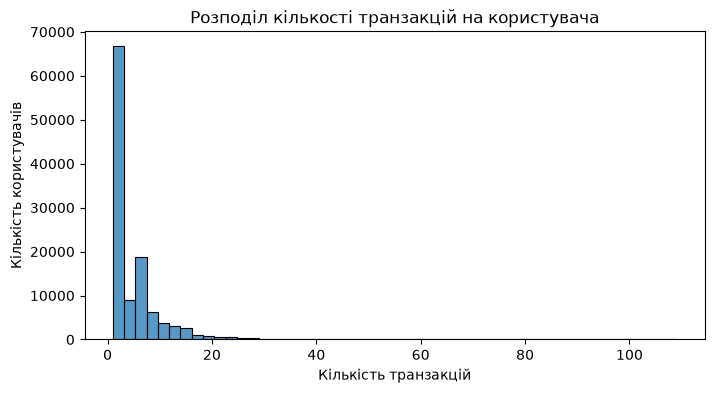

In [193]:
tx_per_user = df.groupby('user_id').size()
print(tx_per_user.describe())

plt.figure(figsize=(8, 4))
sns.histplot(tx_per_user, bins=50)
plt.title('Розподіл кількості транзакцій на користувача')
plt.xlabel('Кількість транзакцій')
plt.ylabel('Кількість користувачів')
plt.show()

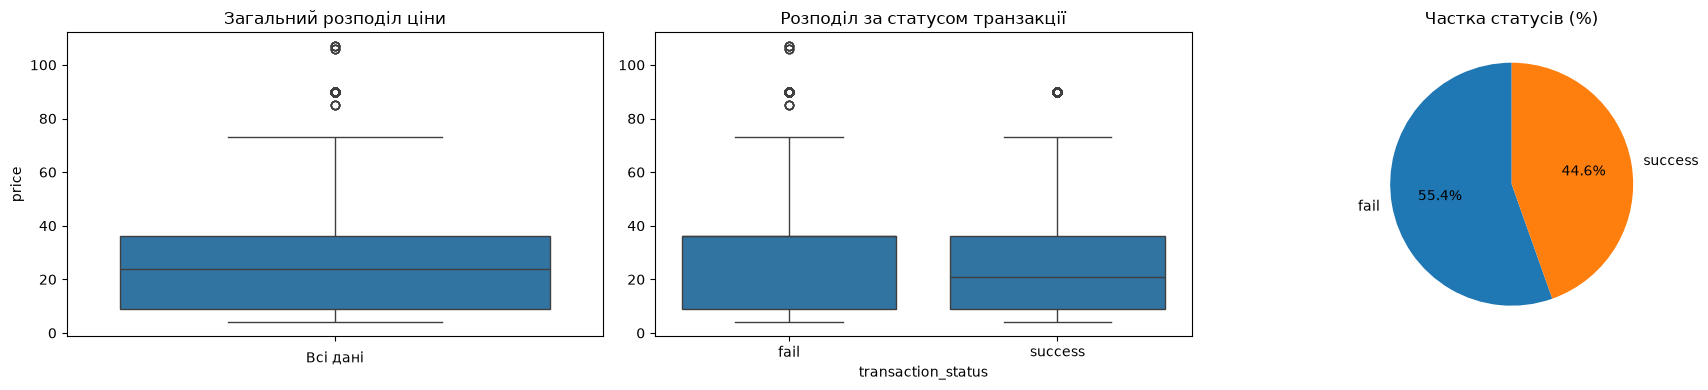

--- Загальна статистика ---
count    566413.000000
mean         24.641491
std          15.621955
min           4.000000
25%           9.000000
50%          24.000000
75%          36.000000
max         107.000000
Name: price, dtype: float64

--- Статистика за статусами ---


,count,mean,std,min,25%,50%,75%,max
transaction_status,,,,,,,,
fail,313954.0,26.658667,16.692784,4.0,9.0,36.0,36.0,107.0
success,252459.0,22.132964,13.771750,4.0,9.0,21.0,36.0,90.0


In [194]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Загальний розподіл price
sns.boxplot(data=df, y='price', ax=axes[0])
axes[0].set_title('Загальний розподіл ціни')
axes[0].set_xlabel('Всі дані')

# 2. Розподіл price за статусами
df_filtered = df[df['transaction_status'].isin(['success', 'fail'])]
sns.boxplot(data=df_filtered, x='transaction_status', y='price', ax=axes[1])
axes[1].set_title('Розподіл за статусом транзакції')
axes[1].set_ylabel('')
axes[1].sharey(axes[0])

# 3. Кругова діаграма часток статусів
status_counts = df_filtered['transaction_status'].value_counts()
axes[2].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%.1f%%',
    startangle=90
)
axes[2].set_title('Частка статусів (%)')

plt.tight_layout()
plt.show()

# Описова статистика
print("--- Загальна статистика ---")
print(df['price'].describe())

print("\n--- Статистика за статусами ---")
df_filtered.groupby('transaction_status')['price'].describe()

Унікальних значень price: 42
price
4.0        5716
5.0      109107
6.0        8546
7.0        1723
8.0          54
9.0       43124
10.0       1377
12.0      16850
14.0       1020
16.0       1164
17.0         29
18.0         97
19.0       2008
20.0      12200
21.0      70589
22.0        160
23.0       1049
24.0      10436
26.0        111
27.0       9404
28.0      14305
29.0       7374
32.0        764
33.0       3223
35.0         13
36.0     196745
38.0      15643
41.0        187
42.0         21
43.0      13025
46.0          5
48.0         17
53.0        526
54.0       4548
55.0       1330
64.0       1109
66.0         40
73.0      10362
85.0          5
90.0       2398
106.0         4
107.0         5
Name: count, dtype: int64


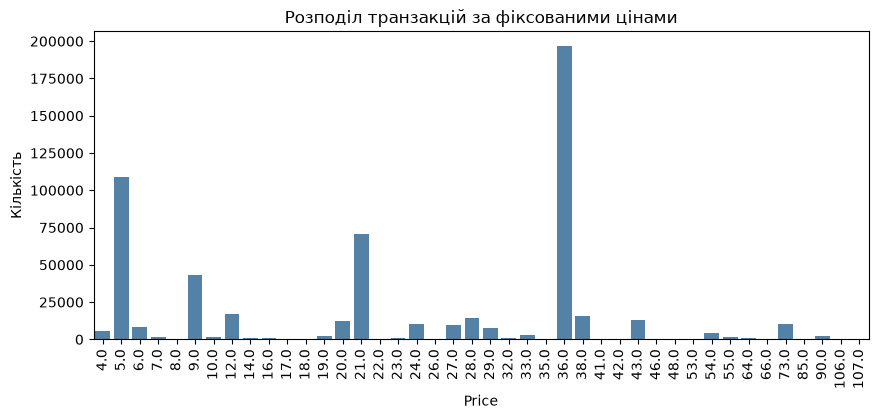

In [195]:
print("Унікальних значень price:", df['price'].nunique())
print(df['price'].value_counts().sort_index())

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='price', order=sorted(df['price'].unique()), color='steelblue')
plt.title('Розподіл транзакцій за фіксованими цінами')
plt.xlabel('Price')
plt.ylabel('Кількість')
plt.xticks(rotation=90)
plt.show()

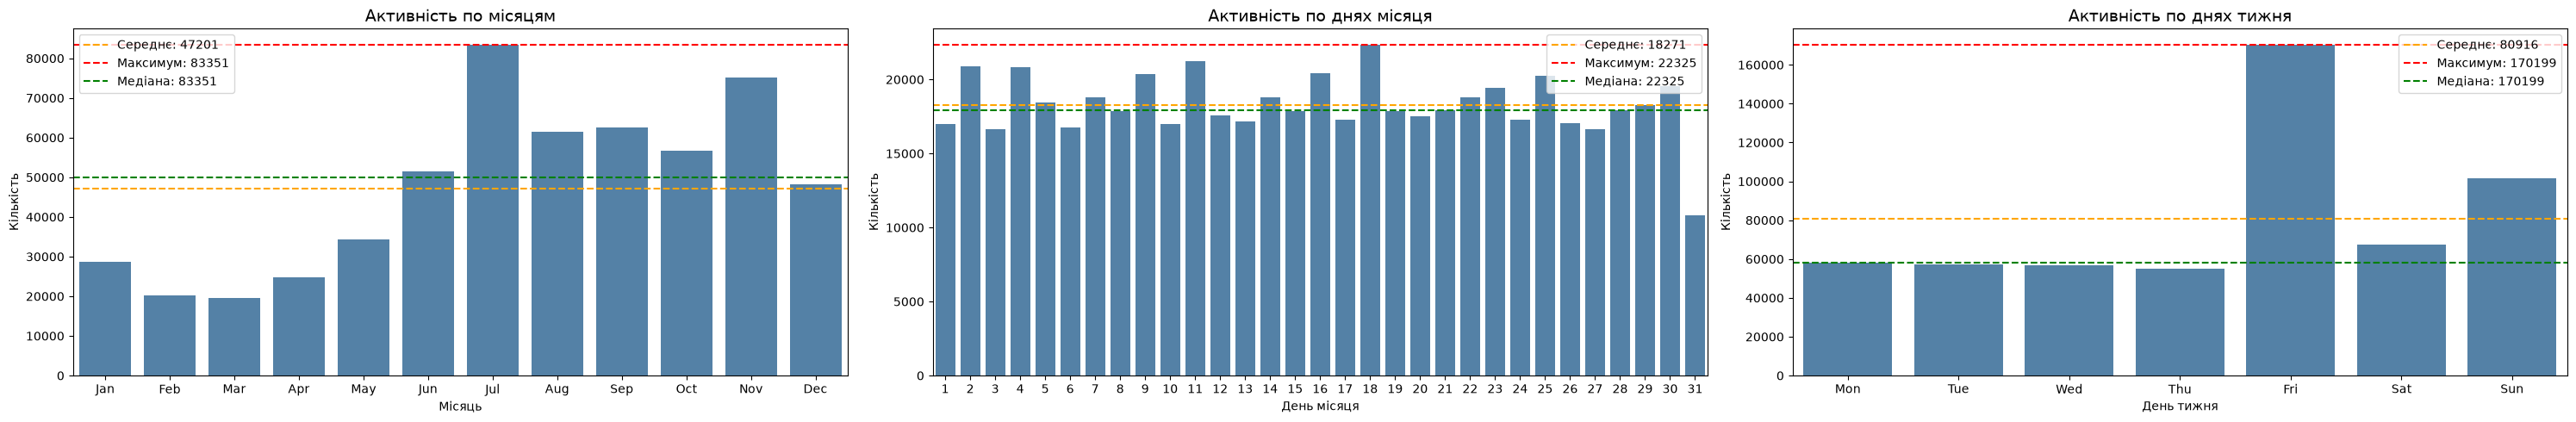

In [205]:
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

df['dayofweek'] = df['event_time'].dt.dayofweek

fig, axes = plt.subplots(1, 3, figsize=(30, 5))

def add_ref_lines(ax, counts):
    mean_val = counts.mean()
    max_val = counts.max()
    median_val = counts.median()
    ax.axhline(mean_val, color='orange', linestyle='--', linewidth=1.5,
               label=f'Середнє: {mean_val:.0f}')
    ax.axhline(max_val, color='red', linestyle='--', linewidth=1.5,
               label=f'Максимум: {max_val:.0f}')
    ax.axhline(median_val, color='green', linestyle='--', linewidth=1.5,
               label=f'Медіана: {max_val:.0f}')
    ax.legend()

# 1. Місяці
month_counts = df['month'].value_counts().sort_index()
sns.countplot(data=df, x='month', order=range(1, 13), ax=axes[0], color='steelblue')
axes[0].set_title('Активність по місяцям', fontsize=14)
axes[0].set_xlabel('Місяць')
axes[0].set_ylabel('Кількість')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(month_names)
add_ref_lines(axes[0], month_counts)

# 2. Дні місяця
day_counts = df['day'].value_counts().sort_index()
sns.countplot(data=df, x='day', order=range(1, 32), ax=axes[1], color='steelblue')
axes[1].set_title('Активність по днях місяця', fontsize=14)
axes[1].set_xlabel('День місяця')
axes[1].set_ylabel('Кількість')
add_ref_lines(axes[1], day_counts)

# 3. Дні тижня
dow_counts = df['dayofweek'].value_counts().sort_index()
sns.countplot(data=df, x='dayofweek', order=range(7), ax=axes[2], color='steelblue')
axes[2].set_title('Активність по днях тижня', fontsize=14)
axes[2].set_xlabel('День тижня')
axes[2].set_ylabel('Кількість')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(weekday_names)
add_ref_lines(axes[2], dow_counts)

plt.tight_layout()
plt.show()

In [206]:
df[df['transaction_status']=='fail']['error_type'].value_counts()

error_type
3.02    134691
3.10     44002
3.08     26442
3.04     15163
4.03     12798
4.05     12772
3.01     12658
2.08      8723
0.01      8468
5.01      5945
4.09      4853
5.08      4431
2.06      4055
4.02      3249
2.11      2581
3.03      2334
2.09      1714
4.04      1320
5.04      1312
2.14      1027
2.15      1015
2.02       902
7.01       895
2.01       534
6.01       483
3.05       144
3.07       104
5.03        83
4.01        71
5.11        70
0.03        58
2.10        31
7.07        30
7.03        30
6.02        21
0.02        15
2.16         7
4.06         6
5.02         4
5.06         4
5.07         2
Name: count, dtype: int64